In [32]:
# loading the tools 
import pandas as pd 
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

# importing the machine learning tools
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
import warnings
warnings.filterwarnings('ignore')

In [33]:
# Step 1: Generate sample data (simulating 3 natural groups)
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=42)

# Step 2: Scale the data (Critical for distance-based algorithms!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Text(0.5, 1.0, 'Graph of optimal k ')

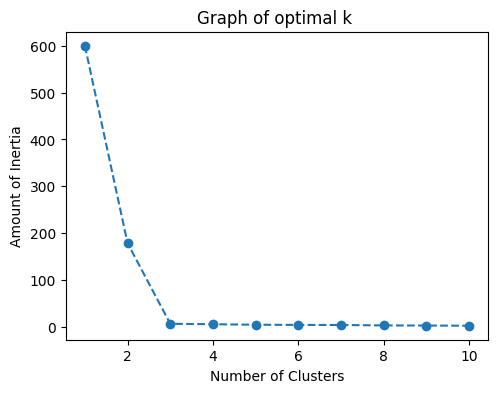

In [ ]:
# Step 1 : finding the optimal k 
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++",random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


# Step 2 : pltting the  Optimal k
plt.figure(figsize=(12,4))
plt.subplot(1 ,2 ,1)# 1 row , 2 columns , 1st position of this plot
plt.plot(range(1,11),wcss,marker="o",linestyle="--")
plt.xlabel("Number of Clusters")
plt.ylabel("Amount of Inertia")
plt.title("Graph of optimal k ")


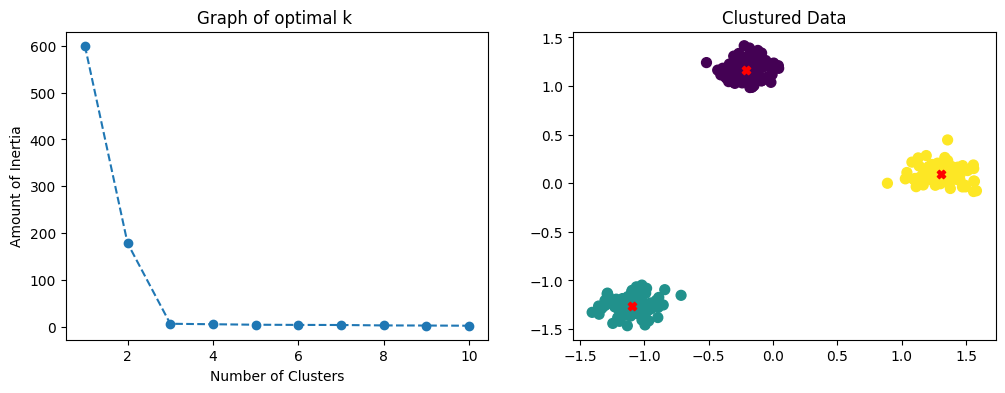

In [41]:
# Step 3 : appling Kmeans on (k=3)
kmeans=KMeans(n_clusters=3,init="k-means++",random_state=42)
kmeans.fit(X_scaled)
labels=kmeans.predict(X_scaled)

#
plt.figure(figsize=(12,4))
plt.subplot(1 ,2 ,1)# 1 row , 2 columns , 1st position of this plot
plt.plot(range(1,11),wcss,marker="o",linestyle="--")
plt.xlabel("Number of Clusters")
plt.ylabel("Amount of Inertia")
plt.title("Graph of optimal k ")



plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=labels,cmap="viridis",s=50)
centers=kmeans.cluster_centers_
plt.scatter(centers[:,0],centers[:,1],c="red",marker="X",label="Centroid")
plt.title("Clustured Data")
plt.show()
